In [1]:
""" Libraries configuration for data preprocessing """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder



In [2]:
data = r'D:\Phone addicted\Smartphone-Addiction-Warning-System-Rebuild-\data\Raw Data\teen_phone_addiction_dataset.csv'
df = pd.read_csv(data)
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


## Data Understanding


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [4]:
df.isna().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [5]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [6]:
df.drop(columns=['ID','Name','Location'], inplace=True)

In [7]:
l = label_encoder = LabelEncoder()
df['Gender'] = l.fit_transform(df['Gender'])

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['School_Grade', 'Phone_Usage_Purpose']


In [9]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(numerical_cols)

['Age', 'Gender', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']


In [10]:
columns_with_zero = df.columns[(df == 0).any()]
print(columns_with_zero)


Index(['Gender', 'Daily_Usage_Hours', 'Social_Interactions', 'Exercise_Hours',
       'Parental_Control', 'Screen_Time_Before_Bed', 'Time_on_Social_Media',
       'Time_on_Gaming', 'Time_on_Education', 'Weekend_Usage_Hours'],
      dtype='object')


In [11]:
# NOTE: Parental_Control is deliberately NOT in this list. It is a genuine
# binary 0/1 flag (1478 zeros, 49.3%), so mean-imputing it turned "no parental
# control" into 0.5073 and mislabelled Unsupervised_Usage below. Mirrored in
# Src/Preprocessed.py ZERO_AS_MISSING - a change to one must change the other.
df['Daily_Usage_Hours'] = df['Daily_Usage_Hours'].replace(0, df['Daily_Usage_Hours'].mean())
df['Social_Interactions'] = df['Social_Interactions'].replace(0, df['Social_Interactions'].mean())
df['Exercise_Hours'] = df['Exercise_Hours'].replace(0, df['Exercise_Hours'].mean())
df['Screen_Time_Before_Bed'] = df['Screen_Time_Before_Bed'].replace(0, df['Screen_Time_Before_Bed'].mean())
df['Time_on_Social_Media'] = df['Time_on_Social_Media'].replace(0, df['Time_on_Social_Media'].mean())
df['Time_on_Gaming'] = df['Time_on_Gaming'].replace(0, df['Time_on_Gaming'].mean())
df['Time_on_Education'] = df['Time_on_Education'].replace(0, df['Time_on_Education'].mean())
df['Weekend_Usage_Hours'] = df['Weekend_Usage_Hours'].replace(0, df['Weekend_Usage_Hours'].mean())


In [12]:
df.describe()

,Age,Gender,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,15.969667,0.990000,5.062506,6.489767,74.947333,5.534367,1.167628,5.590000,5.460333,5.546333,0.507333,1.03660,83.093000,12.609333,2.516728,1.629493,1.101028,5.459667,6.017105,8.881900
std,1.989489,0.813298,1.901582,1.490713,14.684156,2.727224,0.625598,2.890678,2.871557,2.860754,0.500030,0.46039,37.747044,4.611486,0.965659,0.836683,0.571896,2.864572,2.011779,1.609598
min,13.000000,0.000000,0.100000,3.000000,50.000000,1.000000,0.100000,1.000000,1.000000,1.000000,0.000000,0.10000,20.000000,5.000000,0.100000,0.100000,0.100000,1.000000,0.100000,1.000000
25%,14.000000,0.000000,3.800000,5.500000,62.000000,3.000000,0.800000,3.000000,3.000000,3.000000,0.000000,0.70000,51.000000,9.000000,1.800000,1.000000,0.700000,3.000000,4.700000,8.000000
50%,16.000000,1.000000,5.000000,6.500000,75.000000,5.097667,1.040667,6.000000,5.000000,6.000000,1.000000,1.00000,82.000000,13.000000,2.500000,1.525267,1.016333,5.000000,6.000000,10.000000
75%,18.000000,2.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.40000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,19.000000,2.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.60000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


**Usage composition**

In [13]:
df['Tracked_Hours'] = df['Time_on_Social_Media'] + df['Time_on_Gaming'] + df['Time_on_Education']
df['Untracked_Hours'] = df['Daily_Usage_Hours'] - df['Tracked_Hours'] 
df['Leisure_Hours'] = df['Time_on_Social_Media'] + df['Time_on_Gaming']
df['Leisure_Ratio'] = df['Leisure_Hours'] / df['Daily_Usage_Hours']
df['Education_Ratio'] = df['Time_on_Education'] / df['Daily_Usage_Hours']
df['Social_vs_Gaming'] = df['Time_on_Social_Media'] - df['Time_on_Gaming']  

**Weekend/weekday behavior** 

In [14]:
df['Weekend_Escalation'] = df['Weekend_Usage_Hours'] - df['Daily_Usage_Hours']
df['Weekend_Ratio'] = df['Weekend_Usage_Hours'] / df['Daily_Usage_Hours']

In [15]:
df['Minutes_Per_Check'] = (df['Daily_Usage_Hours'] * 60) / df['Phone_Checks_Per_Day']
df['Checks_Per_App'] = df['Phone_Checks_Per_Day'] / df['Apps_Used_Daily']
df['Hours_Per_App'] = df['Daily_Usage_Hours'] / df['Apps_Used_Daily']

In [16]:
df['Sleep_Deficit'] = (9 - df['Sleep_Hours']).clip(lower=0) 
df['Screen_To_Sleep_Ratio'] = df['Daily_Usage_Hours'] / df['Sleep_Hours']
df['Bedtime_Screen_Share'] = df['Screen_Time_Before_Bed'] / df['Daily_Usage_Hours']

In [17]:
df['Offline_Activity'] = df['Exercise_Hours'] + df['Social_Interactions']
df['Online_To_Offline_Ratio'] = df['Daily_Usage_Hours'] / df['Offline_Activity']
df['Family_To_Screen_Ratio'] = df['Family_Communication'] / df['Daily_Usage_Hours']

In [18]:
for c in ['Anxiety_Level', 'Depression_Level', 'Self_Esteem']:
    df[f'{c}_z'] = (df[c] - df[c].mean()) / df[c].std()
df['Distress_Index'] = df[['Anxiety_Level_z', 'Depression_Level_z']].mean(axis=1) - df['Self_Esteem_z']

In [19]:
df['Academic_Per_Usage'] = df['Academic_Performance'] / df['Daily_Usage_Hours']
df['Unsupervised_Usage'] = df['Daily_Usage_Hours'] * (1 - df['Parental_Control'])  # Parental_Control is 0/1
df['Grade_Num'] = df['School_Grade'].str.extract(r'(\d+)').astype(int)  # ordinal, better than one-hot

In [20]:
raw_col = ['School_Grade', 'Sleep_Hours',
       'Academic_Performance', 'Social_Interactions', 'Exercise_Hours',
       'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours']
df.drop(columns=raw_col, inplace=True)

In [21]:
df

,Age,Gender,Daily_Usage_Hours,Addiction_Level,Tracked_Hours,Untracked_Hours,Leisure_Hours,Leisure_Ratio,Education_Ratio,Social_vs_Gaming,...,Offline_Activity,Online_To_Offline_Ratio,Family_To_Screen_Ratio,Anxiety_Level_z,Depression_Level_z,Self_Esteem_z,Distress_Index,Academic_Per_Usage,Unsupervised_Usage,Grade_Num
0,13,0,4.0,10.0,6.500000,-2.500000,5.300000,1.325000,0.300000,1.900000,...,5.100000,0.784314,1.000000,1.525594,-0.856794,0.857699,-0.523299,19.500000,4.0,9
1,17,0,5.5,10.0,6.900000,-1.400000,5.100000,0.927273,0.327273,-2.900000,...,6.040667,0.910496,0.363636,-0.895984,0.536178,-0.890092,0.710189,12.727273,5.5,7
2,13,2,5.8,9.2,2.200000,3.600000,1.800000,0.310345,0.068966,-1.200000,...,8.800000,0.659091,1.034483,-1.241923,-0.856794,1.556816,-2.606174,16.034483,5.8,11
3,18,0,3.1,9.8,5.500000,-2.400000,4.700000,1.516129,0.258065,1.500000,...,9.600000,0.322917,2.580645,1.179654,1.580908,-0.890092,2.270372,25.161290,3.1,12
4,14,2,2.5,8.6,4.600000,-2.100000,3.500000,1.400000,0.440000,1.700000,...,5.100000,0.490196,4.000000,-1.587863,-0.160308,-1.589208,0.715123,22.400000,2.5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,0,3.9,9.8,5.500000,-1.600000,4.500000,1.153846,0.256410,0.900000,...,4.900000,0.795918,2.051282,0.487775,1.580908,-1.239650,2.273991,13.589744,0.0,12
2996,13,0,3.6,5.5,4.925267,-1.325267,4.625267,1.284796,0.083333,1.574733,...,6.040667,0.595961,2.500000,0.833714,0.884421,1.207257,-0.348189,25.833333,0.0,8
2997,14,2,3.2,6.2,5.000000,-1.800000,2.600000,0.812500,0.750000,2.200000,...,2.040667,1.568115,2.812500,-0.550044,-0.856794,1.207257,-1.910676,30.625000,3.2,7
2998,17,0,6.7,10.0,5.800000,0.900000,4.300000,0.641791,0.223881,-0.900000,...,3.200000,2.093750,0.597015,-0.895984,-0.160308,1.207257,-1.735403,10.000000,6.7,9


In [22]:
df.columns

Index(['Age', 'Gender', 'Daily_Usage_Hours', 'Addiction_Level',
       'Tracked_Hours', 'Untracked_Hours', 'Leisure_Hours', 'Leisure_Ratio',
       'Education_Ratio', 'Social_vs_Gaming', 'Weekend_Escalation',
       'Weekend_Ratio', 'Minutes_Per_Check', 'Checks_Per_App', 'Hours_Per_App',
       'Sleep_Deficit', 'Screen_To_Sleep_Ratio', 'Bedtime_Screen_Share',
       'Offline_Activity', 'Online_To_Offline_Ratio', 'Family_To_Screen_Ratio',
       'Anxiety_Level_z', 'Depression_Level_z', 'Self_Esteem_z',
       'Distress_Index', 'Academic_Per_Usage', 'Unsupervised_Usage',
       'Grade_Num'],
      dtype='object')

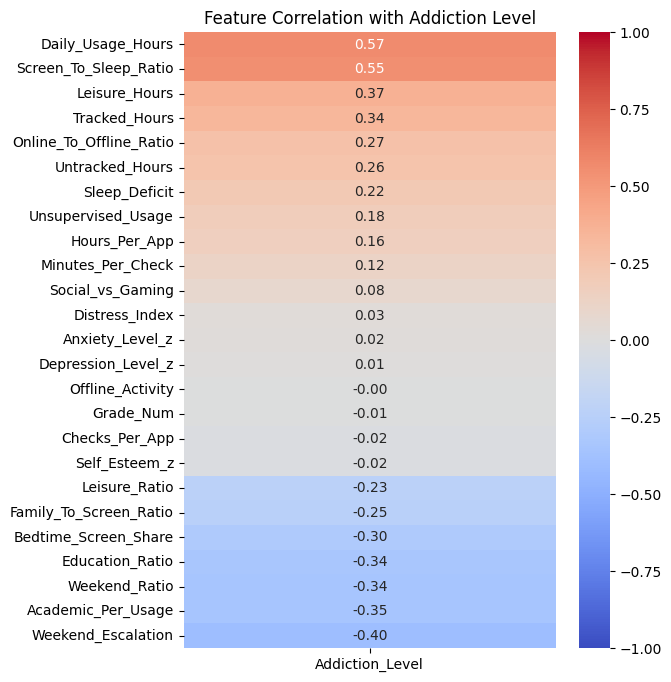

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the list of feature column names
features = [
    'Daily_Usage_Hours',
    'Tracked_Hours',
    'Untracked_Hours',
    'Leisure_Hours',
    'Leisure_Ratio',
    'Education_Ratio',
    'Social_vs_Gaming',
    'Weekend_Escalation', 'Weekend_Ratio', 'Minutes_Per_Check',
    'Checks_Per_App', 'Hours_Per_App', 'Sleep_Deficit',
    'Screen_To_Sleep_Ratio', 'Bedtime_Screen_Share', 'Offline_Activity',
    'Online_To_Offline_Ratio', 'Family_To_Screen_Ratio', 'Anxiety_Level_z',
    'Depression_Level_z', 'Self_Esteem_z', 'Distress_Index',
    'Academic_Per_Usage', 'Unsupervised_Usage', 'Grade_Num'
]

# 2. Compute correlation of selected features specifically against 'Addiction_Level'
correlation = (
    df[features].apply(lambda x: x.corr(df['Addiction_Level'])).to_frame()
)
correlation.columns = ['Addiction_Level']

# 3. Plot single-column correlation heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlation.sort_values(by='Addiction_Level', ascending=False),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
)
plt.title('Feature Correlation with Addiction Level')
plt.show()

In [24]:
df.to_csv('preprocessed_data.csv', index=False)